In [288]:
import numpy as np
import matplotlib.pyplot as plt

In [289]:
## Disk parameters
alpha = 1e-3
M_disk = 0.1 # M_sun
T_0 = 18.9737 # K
a_c = 50 # AU
a_min = 0.1 # AU
a_max = 1000 # AU
d2g = 0.01
D = 0.2
b_tilde = 10
mu = 2.33
v_frag = 100 # cm/s
epsilon_g = 0.5

## Star parameters
M_star = 1.0 # M_sun
R_star = 2.5 # R_sun
T_eff = 4000 # K

## Planetesimal parameters
rho_pltsml = 2.0 # g/cm^3
R_pltsml = 100 # km

## Embryo core parameters
rho_core = 2.0 # g/cm^3

## Constants
G = 6.67e-8 # cm^3/g/s^2
k_B = 1.38e-16 # erg/K
sigma_B = 5.67e-5 # erg/cm^2/s/K^4
m_H = 1.67e-24 # g
M_earth = 5.97e27 # g
M_sun = 1.99e33 # g
R_sun = 6.96e10 # cm
L_sun = 3.839e33 # erg/s
AU = 1.496e13 # cm
year = 3.156e7 # s
sigma_H2 = 2.61e-15 # cm^2

In [290]:
## Disk structure helper functions

def L_star(R_star, T_eff):
    """Calculates the stellar luminosity in solar luminosities assuming a blackbody."""
    return 4 * np.pi * (R_star * R_sun) ** 2 * sigma_B * T_eff ** 4 / L_sun

def Sigma_0(M_disk, a_c):
    """Calculates the normalization constant for the surface density profile."""
    return M_disk * M_sun / (2 * np.pi * (a_c * AU) ** 2)

def Sigma_g(a):
    """Calculates the gas surface density of the disk in g/cm^2."""
    return Sigma_0(M_disk, a_c) * (a / a_c) ** (-1) * np.exp(-a / a_c)

def Sigma_s(a):
    """Calculates the solid surface density of the disk in g/cm^2."""
    return d2g * Sigma_g(a)

def rho_mid(a):
    """Calculates the midplane gas density of the disk in g/cm^3."""
    return Sigma_g(a) / (np.sqrt(2 * np.pi) * H(a) * AU)

def T(a):
    """Calculates the temperature of the disk in K."""
    return T_0 * (a / a_c) ** (-0.5)

def c_s(a):
    """Calculates the sound speed of the disk in cm/s."""
    return np.sqrt(k_B * T(a) / (mu * m_H))

def H(a):
    """Calculates the scale height of the disk in AU."""
    return c_s(a) / Omega_K(a) / AU

def P(a):
    """Calculates the pressure of the disk in g/cm/s^2 assuming an ideal gas."""
    return rho_mid(a) * c_s(a) ** 2

def dP_da(a):
    """Calculates the pressure gradient of the disk at a."""
    a_vals = np.logspace(np.log10(a_min), np.log10(a_max), 10000) # AU
    P_vals = P(a_vals)
    dP_da_vals = np.gradient(P_vals, a_vals * AU)
    return np.interp(np.log10(a), np.log10(a_vals), dP_da_vals)

def dlnP_dlna(a):
    """Calculates dlnP/dlna of the disk at a."""
    return (a * AU) / P(a) * dP_da(a)

def Omega_K(a):
    """Calculates the Keplerian angular velocity in rad/s."""
    return np.sqrt(G * M_star * M_sun / (a * AU) ** 3)

## Streaming instability birth mass

def M_birth(a):
    """Calculates the streaming instability brith mass in Earth masses (Johnston et al 2026)."""
    return 6e-2 * (gamma(a) * np.pi) ** 1.5 * (H(a) / a / 0.05) ** 3 * (M_star / 2.4)

def gamma(a):
    """Calculates the self-gravity parameter (Johnston et al 2026)."""
    return 4 * np.pi * G * rho_mid(a) / (Omega_K(a) ** 2)

## Pebble accretion onset mass

def M_on(a):
    """Calculates the onset mass for pebble accretion in Earth masses (Lorek et al 2022)."""
    return 4.871e-7 * (tau_s(a) / 0.01) * M_star ** (-17/7) * L_star(R_star, T_eff) ** (6/7) * a ** (12/7)

def tau_s(a):
    """Calculates the Stokes number (Lorek et al 2022)."""
    return np.min((tau_s_frag(a), tau_s_drift(a)), axis = 0)

def tau_s_frag(a):
    """Calculates the fragmentation limited Stokes number (Lorek et al 2022)."""
    return v_frag ** 2 / (2 * alpha * c_s(a) ** 2)

def tau_s_drift(a):
    """Calculates the drift limited Stokes number (Lorek et al 2022)."""
    return 3 * np.sqrt(np.pi) / 4 * epsilon_g * d2g / eta(a)

def eta(a):
    """Calculates the eta parameter (Fortier et al 2012)."""
    return -1 * dP_da(a) / (2 * Omega_K(a) ** 2 * a * AU * rho_mid(a))

## Pebble accretion transition mass

def M_tr(a):
    """Calculates the transition mass from the Bondi to the Hill regime in Earth masses (Lorek et al 2022)."""
    return 1.125e-4 * M_star ** (-17/7) * L_star(R_star, T_eff) ** (6/7) * a ** (12/7)

## Pebble isolation mass

def M_iso_pebble(a):
    """Calculates the pebble isolation mass in Earth masses (Lorek et al 2022)."""
    return 25 * (H(a) / a / 0.05) ** 3 * (0.34 * (-3 / np.log10(alpha)) ** 4 + 0.66 ) * (1 - (dlnP_dlna(a) + 2.5) / 6)

## Planetesimal isolation mass

def M_iso_pltsml(a):
    """Calculates the planetesimal isolation mass in Earth masses (Rafikov 2011)."""
    return (2 * np.pi * (a * AU) ** 2 * b_tilde * Sigma_s(a)) ** (3/2) * (3 * M_star * M_sun) ** (-1/2) / M_earth

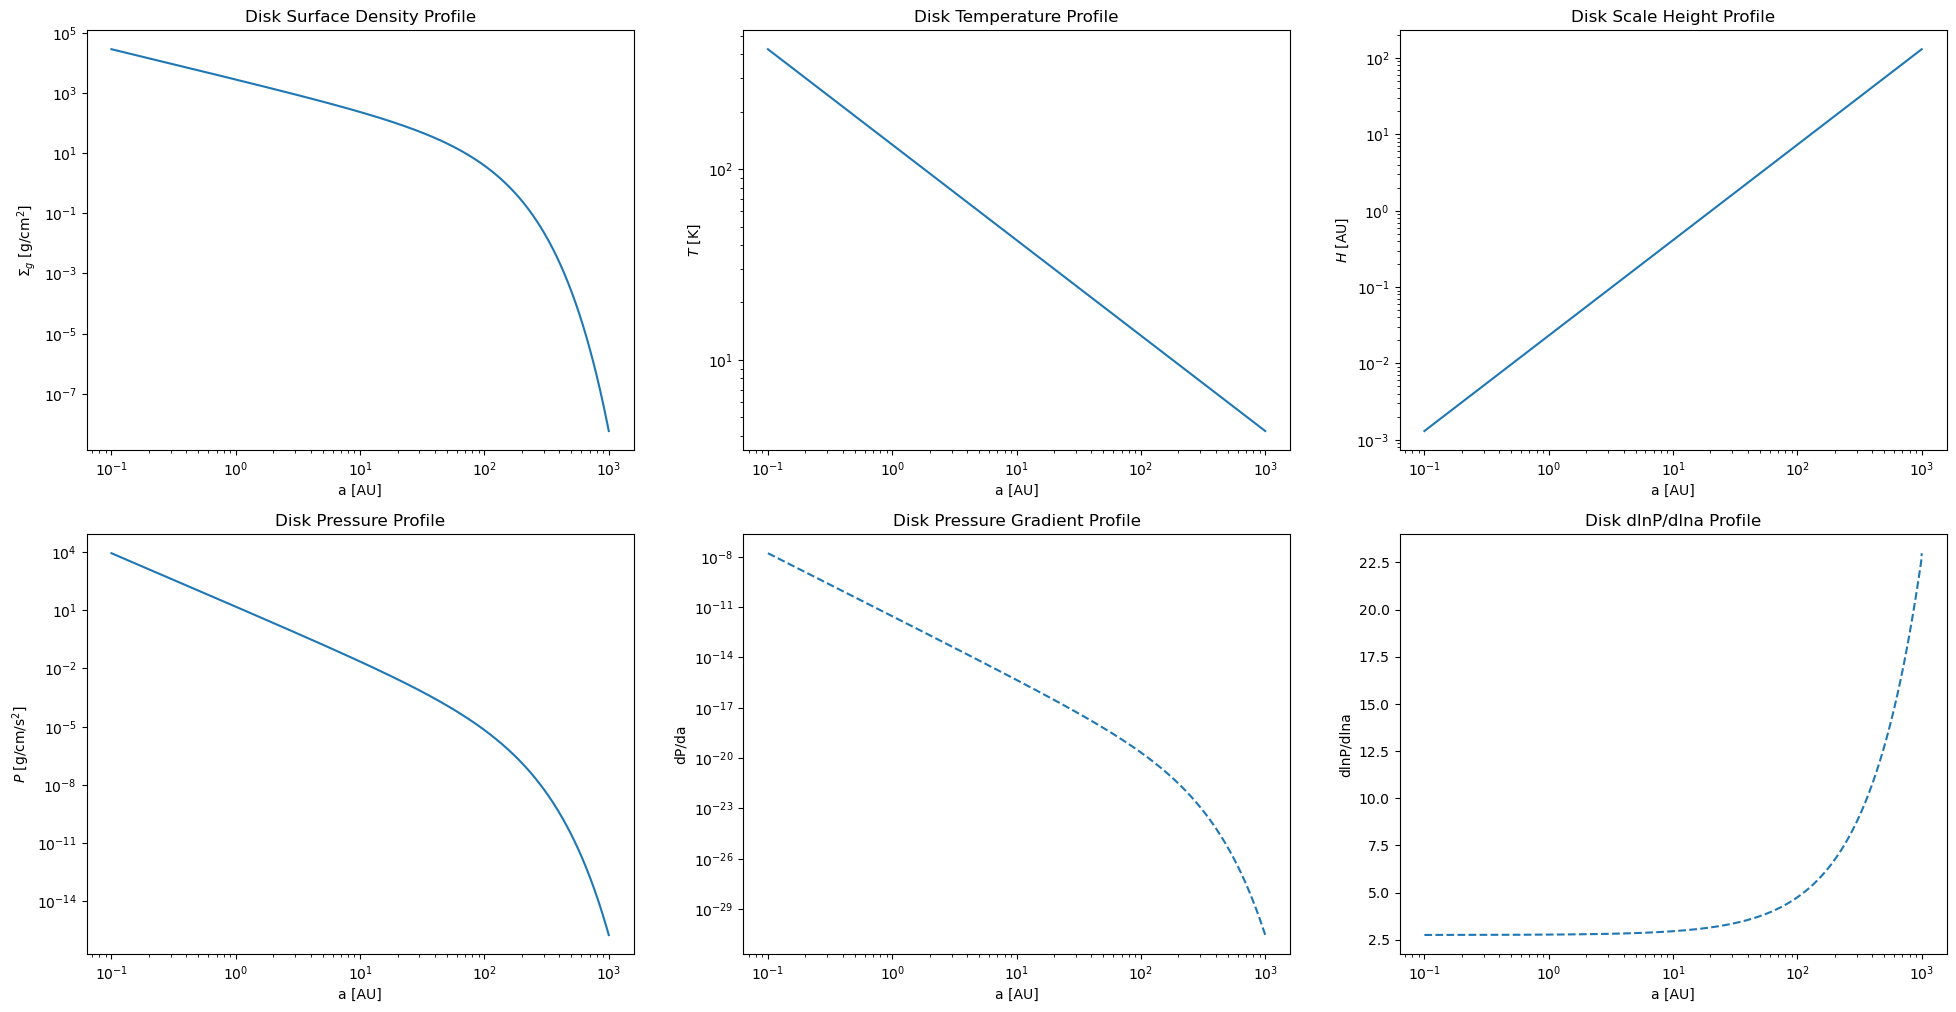

In [291]:
## Plot disk profiles

a_vals = np.logspace(np.log10(a_min), np.log10(a_max), 1000) # AU

fig, ax = plt.subplots(2, 3, figsize = (24, 12))

## Density profile

ax[0, 0].plot(a_vals, Sigma_g(a_vals))

ax[0, 0].set_xscale('log')
ax[0, 0].set_yscale('log')
ax[0, 0].set_xlabel(r'a [AU]')
ax[0, 0].set_ylabel(r'$\Sigma_g$ [g/cm$^2$]')
ax[0, 0].set_title('Disk Surface Density Profile')

## Temperature Profile

ax[0, 1].plot(a_vals, T(a_vals))

ax[0, 1].set_xscale('log')
ax[0, 1].set_yscale('log')
ax[0, 1].set_xlabel(r'a [AU]')
ax[0, 1].set_ylabel(r'$T$ [K]')
ax[0, 1].set_title('Disk Temperature Profile')

## Scale height profile

ax[0, 2].plot(a_vals, H(a_vals))

ax[0, 2].set_xscale('log')
ax[0, 2].set_yscale('log')
ax[0, 2].set_xlabel(r'a [AU]')
ax[0, 2].set_ylabel(r'$H$ [AU]')
ax[0, 2].set_title('Disk Scale Height Profile')

## Pressure profile

ax[1, 0].plot(a_vals, P(a_vals))

ax[1, 0].set_xscale('log')
ax[1, 0].set_yscale('log')
ax[1, 0].set_xlabel(r'a [AU]')
ax[1, 0].set_ylabel(r'$P$ [g/cm/s$^2$]')
ax[1, 0].set_title('Disk Pressure Profile')

## Pressure gradient profile

ax[1, 1].plot(a_vals, [abs(dP_da(a)) for a in a_vals], linestyle = '--')

ax[1, 1].set_xscale('log')
ax[1, 1].set_yscale('log')
ax[1, 1].set_xlabel(r'a [AU]')
ax[1, 1].set_ylabel(r'dP/da')
ax[1, 1].set_title('Disk Pressure Gradient Profile')

## dlnP/dlna profile

ax[1, 2].plot(a_vals, [abs(dlnP_dlna(a)) for a in a_vals], linestyle = '--')

ax[1, 2].set_xscale('log')
ax[1, 2].set_xlabel(r'a [AU]')
ax[1, 2].set_ylabel(r'dlnP/dlna')
ax[1, 2].set_title('Disk dlnP/dlna Profile')

plt.show()

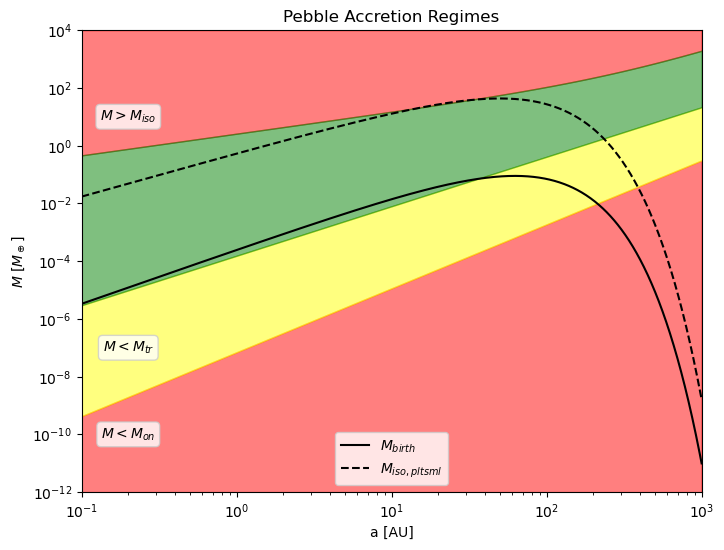

In [325]:
## Plot birth mass

a_vals = np.logspace(np.log10(a_min), np.log10(a_max), 1000) # AU

M_birth_vals = [M_birth(a) for a in a_vals]
M_on_vals = [M_on(a) for a in a_vals]
M_tr_vals = [M_tr(a) for a in a_vals]
M_iso_pebble_vals = [M_iso_pebble(a) for a in a_vals]
M_iso_pltsml_vals = [M_iso_pltsml(a) for a in a_vals]

fig, ax = plt.subplots(figsize = (8, 6))

ax.plot(a_vals, M_birth_vals, color = 'black', label = r'$M_{birth}$')
ax.plot(a_vals, M_iso_pltsml_vals, color = 'black', linestyle = '--', label = r'$M_{iso, pltsml}$')

ax.fill_between(a_vals, M_on_vals, 1e-12, color = 'red', alpha = 0.5)
ax.fill_between(a_vals, M_iso_pebble_vals, 1e4, color = 'red', alpha = 0.5)
ax.fill_between(a_vals, M_on_vals, M_tr_vals, color = 'yellow', alpha = 0.5)
ax.fill_between(a_vals, M_tr_vals, M_iso_pebble_vals, color = 'green', alpha = 0.5)

ax.text(2e-1, 1e-10, r'$M < M_{on}$', ha = 'center', va = 'center', bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.8, edgecolor = '0.8'))
ax.text(2e-1, 1e-7, r'$M < M_{tr}$', ha = 'center', va = 'center', bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.8, edgecolor = '0.8'))
ax.text(2e-1, 1e1, r'$M > M_{iso}$', ha = 'center', va = 'center', bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.8, edgecolor = '0.8'))

ax.margins(0)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'a [AU]')
ax.set_ylabel(r'$M$ [$M_\oplus$]')
ax.set_title('Pebble Accretion Regimes')

plt.legend(loc = 'lower center')
plt.show()